In [36]:
# 1) Imports and configuration
import os
import time
import random
import numpy as np
import torch
from torch.utils.data import IterableDataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

data_path = "/home/pk222/projects/PDEControl_DPC/datasets/heat_smooth_f_dataset.npz"
samples_to_load = 100
seed = 32
train_frac = 0.8
batch_size = 75
num_steps = 1000
log_iter = 10
lr = 1e-3
transition_steps = 2000
decay_rate = 0.9
sample_id = 5
num_samples_to_evaluate = 10

resume_path = ""
resume_strict = True
save_best = True
save_last = True

# RNO preprocessing hyperparameters
sub = 1
T = 16
n_intervals = 5
train_up_to_tipping_point = False
tipping_data_split_prop = 0.67
debug_preprocessing_shapes = True


This notebook is the `sin_embed` variant. It is self-contained.


In [37]:
# 2) Reproducibility and device
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required but not available.")
device = torch.device("cuda")
print(f"Using device: {device}")


Using device: cuda


In [38]:
# 3) Data loading and RNO preprocessing
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset not found: {data_path}")

dataset = np.load(data_path)
solutions = torch.from_numpy(dataset["solutions"][:samples_to_load]).float()
controls = torch.from_numpy(dataset["controls"][:samples_to_load]).float()
x_cord = torch.from_numpy(dataset["x"]).reshape(-1, 1).float()
dt = float(dataset["dt"])

print(f"Loaded {samples_to_load}/{dataset['solutions'].shape[0]} samples:")
print(f"solutions: {tuple(solutions.shape)}")
print(f"controls: {tuple(controls.shape)}")
print(f"x: {tuple(x_cord.shape)}")
print(f"dt: {dt}")

Loaded 100/3000 samples:
solutions: (100, 401, 100)
controls: (100, 400, 4)
x: (100, 1)
dt: 0.001


In [39]:
def round_down(num, divisor):
    return num - (num % divisor)


def chunk_time_axis(arr, chunk_size):
    # arr shape: (ntraj, nt, nfeat) -> (ntraj, n_chunks, chunk_size, nfeat)
    chunks = torch.split(arr, chunk_size, dim=1)
    return torch.stack(chunks, dim=1)

In [40]:
# 1) Align solution/control time lengths and crop to multiple of T
ntraj = min(solutions.shape[0], controls.shape[0])
nt_shared = min(solutions.shape[1] - 1, controls.shape[1])
nt_usable = round_down(nt_shared, T)

solutions = solutions[:ntraj, :nt_usable, :]
controls = controls[:ntraj, :nt_usable, :]

# 2) Optional spatial subsampling on solution/grid only
solutions = solutions[:, :, ::sub]
x_cord = x_cord[::sub]

# 3) Optional pre-tipping crop
if train_up_to_tipping_point:
    tipping_idx = round_down(int(tipping_data_split_prop * solutions.shape[1]), T)
    solutions = solutions[:, :tipping_idx, :]
    controls = controls[:, :tipping_idx, :]

ntraj, nt, nx = solutions.shape
nf = controls.shape[-1]
n_chunks = nt // T

print(f"After preprocessing:")
print(f"solutions: {tuple(solutions.shape)}")
print(f"controls: {tuple(controls.shape)}")
print(f"x: {tuple(x_cord.shape)}")
print(f"ntraj: {ntraj}, nt: {nt}, nx: {nx}, nf: {nf}, n_chunks: {n_chunks}")


After preprocessing:
solutions: (100, 400, 100)
controls: (100, 400, 4)
x: (100, 1)
ntraj: 100, nt: 400, nx: 100, nf: 4, n_chunks: 25


Train/test split by trajectory (same strategy as ks/RNO_KS.py)

In [41]:
# 4) Train/test split by trajectory (same strategy as ks/RNO_KS.py)
n_train_traj = int(train_frac * ntraj)
n_test_traj = ntraj - n_train_traj

sol_train = solutions[:n_train_traj]
sol_test = solutions[n_train_traj:]
ctrl_train = controls[:n_train_traj]
ctrl_test = controls[n_train_traj:]

In [42]:
print(f"Before chunking:")
print(f"sol_train: {tuple(sol_train.shape)}")
print(f"ctrl_train: {tuple(ctrl_train.shape)}")
print(f"sol_test: {tuple(sol_test.shape)}")
print(f"ctrl_test: {tuple(ctrl_test.shape)}")

Before chunking:
sol_train: (80, 400, 100)
ctrl_train: (80, 400, 4)
sol_test: (20, 400, 100)
ctrl_test: (20, 400, 4)


Chunk with T=16: (400 timesteps)

Raw time: 400
Chunk size: T=16
Number of chunks per trajectory: 400/16 = 25

U_chunks: (B, 25, 16, 100, 1)
F_chunks: (B, 25, 16, 4)

In [43]:
# 5) Chunk both streams (keep state and control separate)
sol_train_chunks = chunk_time_axis(sol_train, T).unsqueeze(
    -1
)  # (n_tr, n_chunks, T, nx, 1)
sol_test_chunks = chunk_time_axis(sol_test, T).unsqueeze(
    -1
)  # (n_te, n_chunks, T, nx, 1)

ctrl_train_chunks = chunk_time_axis(ctrl_train, T).unsqueeze(
    -1
)  # (n_tr, n_chunks, T, nf, 1)
ctrl_test_chunks = chunk_time_axis(ctrl_test, T).unsqueeze(
    -1
)  # (n_te, n_chunks, T, nf, 1)

print("After chunking:")
print(f"sol_train_chunks: {tuple(sol_train_chunks.shape)}")
print(f"ctrl_train_chunks: {tuple(ctrl_train_chunks.shape)}")
print(f"sol_test_chunks: {tuple(sol_test_chunks.shape)}")
print(f"ctrl_test_chunks: {tuple(ctrl_test_chunks.shape)}")


After chunking:
sol_train_chunks: (80, 25, 16, 100, 1)
ctrl_train_chunks: (80, 25, 16, 4, 1)
sol_test_chunks: (20, 25, 16, 100, 1)
ctrl_test_chunks: (20, 25, 16, 4, 1)


Build training samples with a sliding window of `n_intervals=5`:

Input uses 5 consecutive chunks: `[i, i+1, i+2, i+3, i+4]`
Target is next chunk: `[i+5]`

So for the model input:

* `timesteps = 5` (history length in chunk units)
* `spatial_dims = (16, 100)` (chunk-internal time, space)
* That gives input like `(batch, 5, channels, 16, 100)` after permute.

Mini picture for one trajectory:

- chunks: `c0 c1 c2 c3 c4 c5 c6 ... c24`
- sample 1: `input=c0..c4`, `target=c5`
- sample 2: `input=c1..c5`, `target=c6`
etc.

In [44]:
def build_windows(sol_chunks, ctrl_chunks, n_intervals_inner):
    x_state, x_ctrl, y_state = [], [], []
    for traj_sol, traj_ctrl in zip(sol_chunks, ctrl_chunks):
        for i in range(sol_chunks.shape[1] - n_intervals_inner - 1):
            x_state.append(traj_sol[i : i + n_intervals_inner])
            x_ctrl.append(traj_ctrl[i : i + n_intervals_inner])
            y_state.append(traj_sol[i + n_intervals_inner])

    x_state = torch.stack(x_state, dim=0)  # (N, n_intervals, T, nx, 1)
    x_ctrl = torch.stack(x_ctrl, dim=0)  # (N, n_intervals, T, nf, 1)
    y_state = torch.stack(y_state, dim=0)  # (N, T, nx, 1)

    x_state = x_state.permute(0, 1, 4, 2, 3).contiguous()  # (N, n_intervals, 1, T, nx)
    x_ctrl = x_ctrl.permute(0, 1, 4, 2, 3).contiguous()  # (N, n_intervals, 1, T, nf)
    y_state = y_state.permute(0, 3, 1, 2).contiguous()  # (N, 1, T, nx)
    return x_state, x_ctrl, y_state


x_train_state, x_train_ctrl, y_train = build_windows(
    sol_train_chunks, ctrl_train_chunks, n_intervals
)
x_test_state, x_test_ctrl, y_test = build_windows(
    sol_test_chunks, ctrl_test_chunks, n_intervals
)

if debug_preprocessing_shapes:
    print("=== RNO preprocessing debug ===")
    print(f"ntraj={ntraj}, nt={nt}, nx={nx}, nf={nf}, n_chunks={n_chunks}")
    print(f"n_train_traj={n_train_traj}, n_test_traj={n_test_traj}")
    print(f"sol_train_chunks: {tuple(sol_train_chunks.shape)}")
    print(f"ctrl_train_chunks: {tuple(ctrl_train_chunks.shape)}")
    print(f"x_train_state: {tuple(x_train_state.shape)}")
    print(f"x_train_ctrl: {tuple(x_train_ctrl.shape)}")
    print(f"y_train: {tuple(y_train.shape)}")
    print(f"x_test_state: {tuple(x_test_state.shape)}")
    print(f"x_test_ctrl: {tuple(x_test_ctrl.shape)}")
    print(f"y_test: {tuple(y_test.shape)}")
    print("=== End preprocessing debug ===")


=== RNO preprocessing debug ===
ntraj=100, nt=400, nx=100, nf=4, n_chunks=25
n_train_traj=80, n_test_traj=20
sol_train_chunks: (80, 25, 16, 100, 1)
ctrl_train_chunks: (80, 25, 16, 4, 1)
x_train_state: (1520, 5, 1, 16, 100)
x_train_ctrl: (1520, 5, 1, 16, 4)
y_train: (1520, 1, 16, 100)
x_test_state: (380, 5, 1, 16, 100)
x_test_ctrl: (380, 5, 1, 16, 4)
y_test: (380, 1, 16, 100)
=== End preprocessing debug ===


In [45]:
# Dataloaders for RNO training (state, control, target_state)
train_loader = DataLoader(
    torch.utils.data.TensorDataset(x_train_state, x_train_ctrl, y_train),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)
test_loader = DataLoader(
    torch.utils.data.TensorDataset(x_test_state, x_test_ctrl, y_test),
    batch_size=batch_size,
    shuffle=False,
    drop_last=True,
)

xb_state, xb_ctrl, yb = next(iter(train_loader))
print(f"train batch state: {tuple(xb_state.shape)}")
print(f"train batch control: {tuple(xb_ctrl.shape)}")
print(f"train batch target: {tuple(yb.shape)}")


train batch state: (75, 5, 1, 16, 100)
train batch control: (75, 5, 1, 16, 4)
train batch target: (75, 1, 16, 100)


In [46]:
# 4) RNO utilities
import operator
from functools import reduce
from tqdm.auto import tqdm


class LpLoss(object):
    def __init__(self, d=2, p=2, size_average=True, reduction=True):
        assert d > 0 and p > 0
        self.d = d
        self.p = p
        self.reduction = reduction
        self.size_average = size_average

    def rel(self, x, y):
        num_examples = x.size()[0]
        diff_norms = torch.norm(
            x.reshape(num_examples, -1) - y.reshape(num_examples, -1), self.p, 1
        )
        y_norms = torch.norm(y.reshape(num_examples, -1), self.p, 1)
        if self.reduction:
            if self.size_average:
                return torch.mean(diff_norms / y_norms)
            return torch.sum(diff_norms / y_norms)
        return diff_norms / y_norms

    def __call__(self, x, y):
        return self.rel(x, y)


def count_params(model):
    c = 0
    for p in list(model.parameters()):
        c += reduce(operator.mul, list(p.size()), 1)
    return c


From documentation: Input tensor `x_train` with shape `(batch, timesteps, in_channels, *spatial_dims)`, where `len(spatial_dims) == self.n_dim`. The channel dimension MUST be at index 2 and the time dimension MUST be at index 1.

Source: https://neuraloperator.github.io/dev/modules/generated/neuralop.models.RNO.html#neuralop.models.RNO

## Audit: current behavior

_Note: This is the sin-embed-strategy notebook._

### Strategy 1 currently in notebook (before refactor)
- State chunks are built as `(n_tr, n_chunks, 16, 100, 1)`.
- Controls are chunked as `(n_tr, n_chunks, 16, 4)`, then broadcast over the `x` axis with `unsqueeze(3).expand(-1, -1, -1, nx, -1)` to `(n_tr, n_chunks, 16, 100, 4)`.
- State and control are concatenated channel-last with `torch.cat([x_sol, x_ctrl], dim=-1)` to form `(N, n_intervals, 16, 100, 5)`.

### Exact model input and channels
- `in_channels` is set from `x_train.shape[-1]`, so the model is configured with `in_channels=5` (expected), `out_channels=1`.
- Batches are passed to `model.predict` as `x_in = x_batch.permute(0, 1, 4, 2, 3)`.
- Exact forward input shape is `(B, n_intervals, 5, 16, 100)`.

### Training target and loss behavior
- Target is only the next chunk: `y_sol[i + n_intervals]` with shape `(B, 16, 100, 1)`.
- Training uses `model.predict(x_in, num_steps=1)[:, -1]`, then permutes to `(B, 16, 100, 1)`.
- Loss is one-step relative L2 (`LpLoss`) over the full chunk field, not sequence loss over multiple future steps.
- This is teacher-forced history input (fixed ground-truth context window), not free-run multi-step autoregressive training.

### Existing rollout path
- Rollout comparison is in cells 18-19 via `evaluate_rollout_steps`.
- It uses `model.predict(x_in, num_steps=h)` from a fixed input window.
- For `h > 1`, future controls are not injected at each predicted step; rollout proceeds from predicted states only.


In [47]:
# 5a) Sin-embed imports + embedding probe Example adapted from Neural Operator docs:
# https://neuraloperator.github.io/dev/auto_examples/layers/plot_sinusoidal_embeddings.html

from neuralop.models import RNO
from neuralop.layers.embeddings import SinusoidalEmbedding

try:
    from rno_functions import ControlLifterSin, RNOControlARSinEmbed
except ModuleNotFoundError:
    from heat.rno_functions import ControlLifterSin, RNOControlARSinEmbed

model_input_mode = "sin_embed"
control_dim = int(x_train_ctrl.shape[-1])

probe_embedding = SinusoidalEmbedding(
    in_channels=control_dim,
    num_frequencies=13,
    embedding_type="transformer",  # options: "nerf", "transformer"
    max_positions=10000,
)
probe_x = torch.randn(2, 7, control_dim)
probe_y = probe_embedding(probe_x)
print("SinusoidalEmbedding probe:", tuple(probe_x.shape), "->", tuple(probe_y.shape))
print("Probe out_channels:", probe_embedding.out_channels)


SinusoidalEmbedding probe: (2, 7, 4) -> (2, 7, 104)
Probe out_channels: 104


In [ ]:
# 5b) Sin-embed input builder


def build_rno_input(x_state, x_ctrl):
    # x_state: (B, T_hist, 1, 16, 100), x_ctrl: (B, T_hist, 1, 16, control_dim)
    return RNOControlARSinEmbed.build_rno_input(x_state, x_ctrl, control_lifter)


In [49]:
# 5c) Sin-embed model + optimizer setup
modes1 = 20
modes2 = 20
width = 28
n_layers = 3
domain_padding = [0.1, 0]

in_channels = 2
# ControlLifterSin is a plain callable; .to(device) is forwarded to its internal embedding module.
control_lifter = ControlLifterSin(
    control_dim=control_dim,
    embed_dim=100,
    num_frequencies=13,
    embedding_type="transformer",
    max_positions=10000,
)
out_channels = 1
learning_rate = lr
weight_decay = 1e-4
scheduler_step = 50
scheduler_gamma = 0.5
epochs = 25
save_weights = True

model = RNO(
    n_modes=(modes1, modes2),
    hidden_channels=width,
    in_channels=in_channels,
    out_channels=out_channels,
    n_layers=n_layers,
    domain_padding=domain_padding,
).to(device)

ar_model = RNOControlARSinEmbed(rno=model, control_lifter=control_lifter).to(device)

print(f"model_input_mode={model_input_mode}")
print(f"control_dim={control_dim}")
print(f"in_channels={in_channels}, out_channels={out_channels}")
print("Model parameters:", count_params(model))

opt_params = list(model.parameters())
optimizer = torch.optim.Adam(opt_params, lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=scheduler_step, gamma=scheduler_gamma
)
lploss = LpLoss(size_average=False)


model_input_mode=sin_embed
control_dim=4
in_channels=2, out_channels=1
Model parameters: 3138197


In [50]:
# 6) Shape sanity (non-invasive debug cell)
model.eval()

with torch.no_grad():
    xb_state, xb_ctrl, yb = next(iter(train_loader))
    xb_state = xb_state.to(device).float()  # (B, T_hist, 1, 16, 100)
    xb_ctrl = xb_ctrl.to(device).float()  # (B, T_hist, 1, 16, n_ctrl)
    yb = yb.to(device).float()  # (B, 1, 16, 100)

    x_in_dbg = build_rno_input(
        xb_state,
        xb_ctrl,
    )  # (B, T_hist, C_in, 16, 100)
    # y_pred_dbg = model.predict(x_in_dbg, num_steps=1)[:, -1]  # (B, 1, 16, 100)
    y_pred_dbg = model.predict(x_in_dbg, num_steps=1)  # (B, 1, 16, 100)

    print("dataset batch output:")
    print("  state:", tuple(xb_state.shape))
    print("  control:", tuple(xb_ctrl.shape))
    print("  target:", tuple(yb.shape))
    print("model input tensor:", tuple(x_in_dbg.shape))
    print("model output tensor:", tuple(y_pred_dbg.shape))
    print("loss inputs:", tuple(y_pred_dbg.shape), tuple(yb.shape))

model.train()


dataset batch output:
  state: (75, 5, 1, 16, 100)
  control: (75, 5, 1, 16, 4)
  target: (75, 1, 16, 100)
model input tensor: (75, 5, 2, 16, 100)
model output tensor: (75, 1, 1, 16, 100)
loss inputs: (75, 1, 1, 16, 100) (75, 1, 16, 100)


RNO(
  (domain_padding): DomainPadding()
  (positional_embedding): GridEmbeddingND()
  (layers): ModuleList(
    (0-2): 3 x RNOBlock(
      (cell): RNOCell(
        (input_gates): ModuleList(
          (0-2): 3 x FNOBlocks(
            (convs): ModuleList(
              (0): SpectralConv(
                (weight): DenseTensor(shape=torch.Size([28, 28, 20, 11]), rank=None)
              )
            )
            (fno_skips): ModuleList(
              (0): Flattened1dConv(
                (conv): Conv1d(28, 28, kernel_size=(1,), stride=(1,), bias=False)
              )
            )
            (channel_mlp): ModuleList(
              (0): ChannelMLP(
                (fcs): ModuleList(
                  (0): Conv1d(28, 14, kernel_size=(1,), stride=(1,))
                  (1): Conv1d(14, 28, kernel_size=(1,), stride=(1,))
                )
              )
            )
            (channel_mlp_skips): ModuleList(
              (0): SoftGating()
            )
          )
        )
      

In [51]:
# 7) RNO training loop (control-aware input construction)
num_train_samples = x_train_state.shape[0]
num_test_samples = x_test_state.shape[0]
training_loss_history = []
test_loss_history = []

print("Begin RNO training:")
for ep in range(1, epochs + 1):
    model.train()

    t_start = time.time()
    train_l2 = 0.0

    for x_state_batch, x_ctrl_batch, y_batch in tqdm(train_loader, leave=False):
        x_state_batch = x_state_batch.to(device).float()  # (B, T_hist, 1, 16, 100)
        x_ctrl_batch = x_ctrl_batch.to(device).float()  # (B, T_hist, 1, 16, n_ctrl)
        y_batch = y_batch.to(device).float()  # (B, 1, 16, 100)

        x_in = build_rno_input(
            x_state_batch,
            x_ctrl_batch,
        )  # (B, T_hist, C_in, 16, 100)
        out = model.predict(x_in, num_steps=1)[:, -1]  # (B, 1, 16, 100)

        loss = lploss(out, y_batch)
        train_l2 += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

    model.eval()

    test_l2 = 0.0
    with torch.no_grad():
        for x_state_batch, x_ctrl_batch, y_batch in test_loader:
            x_state_batch = x_state_batch.to(device).float()
            x_ctrl_batch = x_ctrl_batch.to(device).float()
            y_batch = y_batch.to(device).float()

            x_in = build_rno_input(
                x_state_batch,
                x_ctrl_batch,
            )
            out = model.predict(x_in, num_steps=1)[:, -1]
            test_l2 += lploss(out, y_batch).item()

    train_l2 /= num_train_samples
    test_l2 /= num_test_samples
    training_loss_history.append(train_l2)
    test_loss_history.append(test_l2)

    print(
        f"Epoch {ep:03d}/{epochs} | time={time.time() - t_start:.2f}s | train_l2={train_l2:.4e} | test_l2={test_l2:.4e}"
    )


Begin RNO training:


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 001/25 | time=10.35s | train_l2=1.1716e+00 | test_l2=9.1957e-01


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 002/25 | time=5.42s | train_l2=8.4661e-01 | test_l2=8.3924e-01


...

Epoch 023/25 | time=5.53s | train_l2=6.8161e-01 | test_l2=8.3237e-01


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 024/25 | time=5.50s | train_l2=6.8289e-01 | test_l2=8.3238e-01


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 025/25 | time=5.49s | train_l2=6.8159e-01 | test_l2=8.3240e-01


In [52]:
# 8) Save model weights
if save_weights:
    result_dir = os.path.join(os.getcwd(), f"result_rno_{seed}_sin_embed")
    os.makedirs(result_dir, exist_ok=True)
    model_path = os.path.join(result_dir, "rno_model_last.pt")
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "epochs": epochs,
            "seed": seed,
            "config": {
                "modes1": modes1,
                "modes2": modes2,
                "width": width,
                "model_input_mode": model_input_mode,
                "in_channels": in_channels,
                "out_channels": out_channels,
                "n_layers": n_layers,
                "domain_padding": domain_padding,
                "learning_rate": learning_rate,
                "weight_decay": weight_decay,
                "scheduler_step": scheduler_step,
                "scheduler_gamma": scheduler_gamma,
                "T": T,
                "n_intervals": n_intervals,
                "sub": sub,
            },
            "train_loss_history": training_loss_history,
            "test_loss_history": test_loss_history,
        },
        model_path,
    )
    print(f"Saved weights to: {model_path}")
else:
    print("save_weights=False, skipping model save.")


Saved weights to: /home/pk222/projects/tipping-point-forecast/heat/result_rno_32_sin_embed/rno_model_last.pt


In [53]:
# 9) Control-aware rollout example (uses exogenous controls at each step)
model.eval()

with torch.no_grad():
    xb_state, xb_ctrl, _ = next(iter(test_loader))
    xb_state = xb_state.to(device).float()  # (B, T_hist, 1, 16, 100)
    xb_ctrl = xb_ctrl.to(device).float()  # (B, T_hist, 1, 16, n_ctrl)

    u0 = xb_state[:, 0]  # (B, 1, 16, 100)
    ctrl_seq = xb_ctrl[:, :2]  # (B, 2, 1, 16, n_ctrl)
    rollout_pred = ar_model.rollout(u0=u0, ctrl_seq=ctrl_seq, steps=2)

    print("u0:", tuple(u0.shape))
    print("ctrl_seq:", tuple(ctrl_seq.shape))
    print("rollout_pred:", tuple(rollout_pred.shape))


u0: (75, 1, 16, 100)
ctrl_seq: (75, 2, 1, 16, 4)
rollout_pred: (75, 3, 1, 16, 100)


In [54]:
# 10) Unit-test-like shape checks + tiny numerical smoke test (1 batch)
model.eval()

xb_state, xb_ctrl, _ = next(iter(train_loader))
xb_state = xb_state.to(device).float()  # (B, T_hist, 1, 16, 100)
xb_ctrl = xb_ctrl.to(device).float()  # (B, T_hist, 1, 16, n_ctrl)

B, T_hist = xb_state.shape[0], xb_state.shape[1]
n_ctrl = xb_ctrl.shape[-1]

x_in_sin = build_rno_input(
    xb_state,
    xb_ctrl,
)  # (B, T_hist, 2, 16, 100)
assert x_in_sin.shape == (B, T_hist, 2, 16, 100), x_in_sin.shape

u0_hist = xb_state[:, 0]  # (B, 1, 16, 100)
with torch.no_grad():
    y_pred_roll = ar_model.rollout(
        u0=u0_hist,
        ctrl_seq=xb_ctrl[:, :T_hist],
        steps=T_hist,
    )  # (B, T_hist+1, 1, 16, 100)
    y_pred = y_pred_roll[:, 1:]  # (B, T_hist, 1, 16, 100)
assert y_pred.shape == (B, T_hist, 1, 16, 100), y_pred.shape

u0 = xb_state[:, 0]  # (B, 1, 16, 100)
ctrl_two = xb_ctrl[:, :2]  # (B, 2, 1, 16, n_ctrl)
with torch.no_grad():
    rollout_out = ar_model.rollout(u0=u0, ctrl_seq=ctrl_two, steps=2)
assert rollout_out.shape == (B, 3, 1, 16, 100), rollout_out.shape

with torch.no_grad():
    rollout_tf = ar_model.rollout(
        u0=u0,
        ctrl_seq=ctrl_two,
        steps=2,
        teacher_forcing_states=xb_state[:, :2],
        use_teacher_forcing=True,
    )
assert rollout_tf.shape == (B, 3, 1, 16, 100), rollout_tf.shape

u0_rand = torch.randn(2, 1, 16, 100, device=device)
ctrl_rand = torch.randn(2, 2, 1, 16, n_ctrl, device=device)
with torch.no_grad():
    rollout_rand = ar_model.rollout(u0=u0_rand, ctrl_seq=ctrl_rand, steps=2)
assert torch.isfinite(rollout_rand).all(), "Rollout produced non-finite values"

print("Sin-embed shape checks and rollout smoke tests passed.")


Sin-embed shape checks and rollout smoke tests passed.


## 11) Single-Trajectory Native Rollout Test (with controls)
Evaluation-only native rollout over chunk steps using exogenous controls.


variant: sin_embed
traj_sol: (25, 16, 100, 1)
traj_ctrl: (25, 16, 4, 1)
u0: (1, 1, 16, 100)
ctrl_seq: (1, 5, 1, 16, 4)
y_true_chunks: (5, 16, 100, 1)
pred_roll shape: (1, 6, 1, 16, 100)
pred_chunks shape: (5, 16, 100, 1)
true_chunks shape: (5, 16, 100, 1)
Rollout MSE (h=5): 1.6118e+00
Rollout relative L2 (h=5): 8.8540e-01


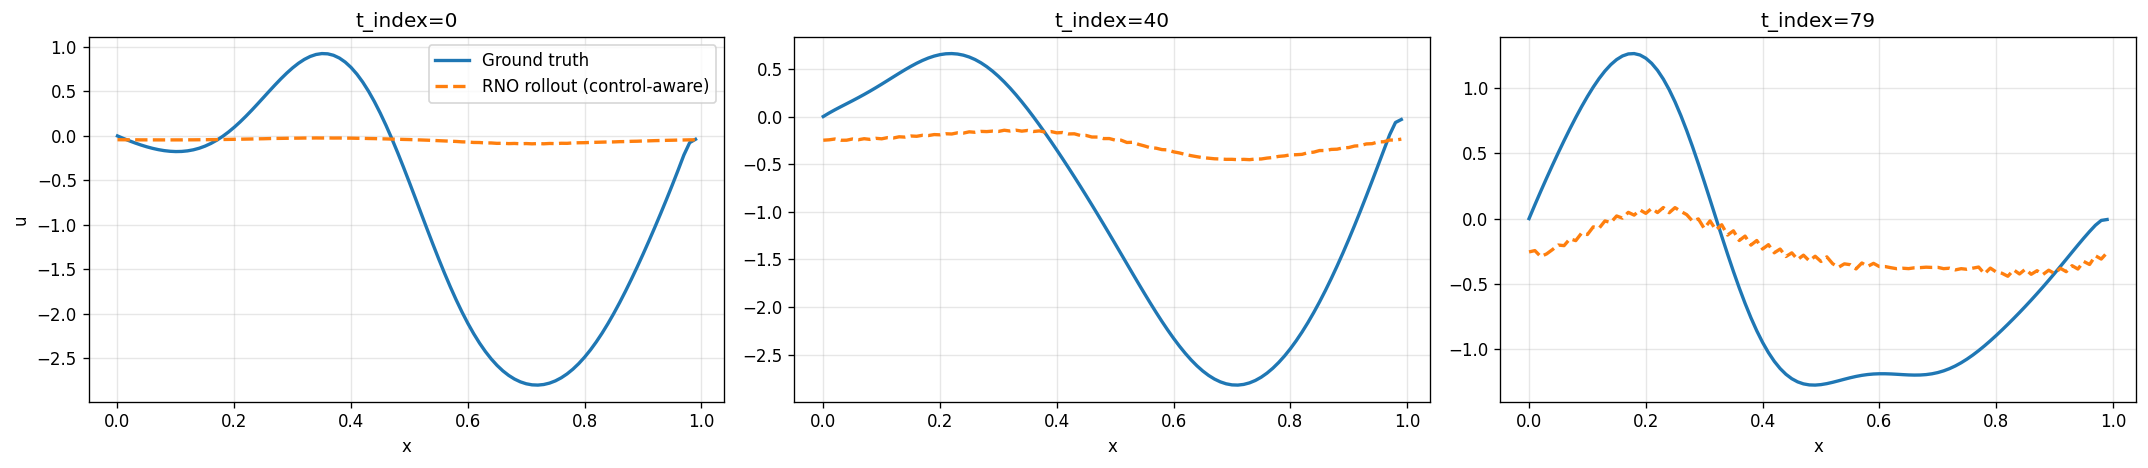

In [ ]:
# 11) Single-Trajectory Native Rollout Test (with controls)
# Native rolled axis: chunk index k (trajectory window steps), not chunk-internal time.
# Control alignment rule: use ctrl_seq[:, k] with current state u_k to predict u_{k+1}.

rollout_h_native = 5
sample_id_native = 0
start_chunk_native = 0
assert rollout_h_native >= 1

traj_sol = sol_test_chunks[sample_id_native]  # (n_chunks, chunk_len, nx, 1)
traj_ctrl = ctrl_test_chunks[sample_id_native]  # (n_chunks, chunk_len, n_ctrl, 1)

if traj_sol.shape[0] != traj_ctrl.shape[0]:
    raise ValueError(
        f"State/control chunk count mismatch: sol={traj_sol.shape[0]}, ctrl={traj_ctrl.shape[0]}"
    )

max_start = traj_sol.shape[0] - n_intervals - rollout_h_native
if max_start < 0:
    raise ValueError(
        f"Not enough chunks for rollout_h={rollout_h_native}. Have n_chunks={traj_sol.shape[0]}, n_intervals={n_intervals}."
    )

start = min(start_chunk_native, max_start)
chunk_len = int(traj_sol.shape[1])
nx_local = int(traj_sol.shape[2])
n_ctrl_local = int(traj_ctrl.shape[2])

# Initial condition is the last state in the history window [start, ..., start+n_intervals-1].
u0_chunk = traj_sol[start + n_intervals - 1]  # (chunk_len, nx, 1)
u0 = u0_chunk.permute(2, 0, 1).unsqueeze(0).to(device).float()  # (1, 1, chunk_len, nx)

# Controls are exogenous and aligned with current rollout state u_k.
ctrl_seq_chunks = traj_ctrl[
    start + n_intervals - 1 : start + n_intervals - 1 + rollout_h_native
]  # (rollout_h, chunk_len, n_ctrl, 1)
ctrl_seq = (
    ctrl_seq_chunks.permute(0, 3, 1, 2).unsqueeze(0).to(device).float()
)  # (1, rollout_h, 1, chunk_len, n_ctrl)

# Ground-truth next chunks to compare against predicted rollout chunks.
y_true_chunks = traj_sol[
    start + n_intervals : start + n_intervals + rollout_h_native
]  # (rollout_h, chunk_len, nx, 1)

print("variant:", "sin_embed")
print("traj_sol:", tuple(traj_sol.shape))
print("traj_ctrl:", tuple(traj_ctrl.shape))
print("u0:", tuple(u0.shape))
print("ctrl_seq:", tuple(ctrl_seq.shape))
print("y_true_chunks:", tuple(y_true_chunks.shape))

model.eval()
ar_model.eval()
with torch.no_grad():
    pred_roll = ar_model.rollout(
        u0=u0,
        ctrl_seq=ctrl_seq,
        steps=rollout_h_native,
    )  # (1, rollout_h+1, 1, chunk_len, nx)

if not torch.isfinite(pred_roll).all():
    raise ValueError("Non-finite values encountered in native control-aware rollout.")

pred_chunks = (
    pred_roll[0, 1:].permute(0, 2, 3, 1).detach().cpu()
)  # (rollout_h, chunk_len, nx, 1)
true_chunks = y_true_chunks.detach().cpu()  # (rollout_h, chunk_len, nx, 1)

assert pred_chunks.shape == true_chunks.shape, (
    pred_chunks.shape,
    true_chunks.shape,
)

pred_flat = pred_chunks.squeeze(-1).reshape(rollout_h_native * chunk_len, nx_local)
true_flat = true_chunks.squeeze(-1).reshape(rollout_h_native * chunk_len, nx_local)

mse_roll = torch.mean((pred_flat - true_flat) ** 2).item()
rel_l2_roll = (
    torch.linalg.norm(pred_flat - true_flat) / (torch.linalg.norm(true_flat) + 1e-12)
).item()

print(f"pred_roll shape: {tuple(pred_roll.shape)}")
print(f"pred_chunks shape: {tuple(pred_chunks.shape)}")
print(f"true_chunks shape: {tuple(true_chunks.shape)}")
print(f"Rollout MSE (h={rollout_h_native}): {mse_roll:.4e}")
print(f"Rollout relative L2 (h={rollout_h_native}): {rel_l2_roll:.4e}")

x_axis = x_cord.squeeze().cpu().numpy()
ids = [0, max(0, (rollout_h_native * chunk_len) // 2), rollout_h_native * chunk_len - 1]
fig, axes = plt.subplots(1, 3, figsize=(18, 4), dpi=120)
for ax, tid in zip(axes, ids):
    ax.plot(
        x_axis,
        true_flat[tid].numpy(),
        label="Ground truth",
        color="#1f77b4",
        linewidth=2,
    )
    ax.plot(
        x_axis,
        pred_flat[tid].numpy(),
        label="RNO rollout (control-aware)",
        color="#ff7f0e",
        linestyle="--",
        linewidth=2,
    )
    ax.set_title(f"t_index={tid}")
    ax.set_xlabel("x")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("u")
axes[0].legend(loc="best")
plt.tight_layout()
plt.show()
